In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import seaborn as sns
sns.set_style("whitegrid")

# Data Preparation

### Import NOAA Data for Seattle

In [37]:
df_seattle = pd.read_csv("/Users/michael/Documents/SeattleU/5100/Weather/data/seattle_rain.csv")

### Import NOAA Data for Philadelphia

Due to the max size for a single NOAA download, the Philadelphia dataset was downloaded in three different sections

In [3]:
df_phl1 = pd.read_csv("/Users/michael/Documents/SeattleU/5100/Weather/data/phl_rain1.csv")
df_phl2 = pd.read_csv("/Users/michael/Documents/SeattleU/5100/Weather/data/phl_rain2.csv")
df_phl3 = pd.read_csv("/Users/michael/Documents/SeattleU/5100/Weather/data/phl_rain3.csv")

Combine data from 3 seperate dataframes into one, combined dataframe

In [4]:
df_phl = pd.concat([df_phl1, df_phl2, df_phl3], ignore_index=True)

Inspect the dataframe 

In [5]:
df_phl.head()

,STATION,NAME,DATE,PRCP,SNOW,SNWD
0,USW00013739,"PHILADELPHIA INTERNATIONAL AIRPORT, PA US",2018-01-01,0.00,0.0,1.2
1,USW00013739,"PHILADELPHIA INTERNATIONAL AIRPORT, PA US",2018-01-02,0.00,0.0,0.0
2,USW00013739,"PHILADELPHIA INTERNATIONAL AIRPORT, PA US",2018-01-03,0.00,0.0,0.0
3,USW00013739,"PHILADELPHIA INTERNATIONAL AIRPORT, PA US",2018-01-04,0.25,4.1,0.0
4,USW00013739,"PHILADELPHIA INTERNATIONAL AIRPORT, PA US",2018-01-05,0.00,0.0,3.1


In [6]:
df_phl["STATION"].unique()

array(['USW00013739'], dtype=object)

In [7]:
df_phl["STATION"].nunique()

1

In [8]:
df_phl['DATE'].agg(['min','max'])

min    2018-01-01
max    2022-12-31
Name: DATE, dtype: object

In [9]:
df_phl["DATE"] = pd.to_datetime(df_phl["DATE"])
df_seattle["DATE"] = pd.to_datetime(df_seattle["DATE"])

/var/folders/dv/p_52lnsx0nb3phkqsyqzbtj40000gn/T/ipykernel_7121/2014070821.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_seattle["DATE"] = pd.to_datetime(df_seattle["DATE"])


In [10]:
df_phl.dtypes

STATION            object
NAME               object
DATE       datetime64[ns]
PRCP              float64
SNOW              float64
SNWD              float64
dtype: object

In [11]:
df_seattle.dtypes

STATION            object
NAME               object
DATE       datetime64[ns]
DAPR              float64
MDPR              float64
PRCP              float64
SNOW              float64
SNWD              float64
WESD              float64
WESF              float64
dtype: object

In [35]:
print(df_seattle.shape)
print(df_phl.shape)

(1658, 10)
(1826, 6)


Merge the Seattle and Philadelphia dataframes

In [14]:
df = df_phl[['DATE','PRCP']].merge(df_seattle[['DATE','PRCP']], on='DATE', how='outer')

In [15]:
df.head()

,DATE,PRCP_x,PRCP_y
0,2018-01-01,0.00,0.00
1,2018-01-02,0.00,0.00
2,2018-01-03,0.00,0.00
3,2018-01-04,0.25,0.00
4,2018-01-05,0.00,0.25


In [16]:
df = pd.melt(df, id_vars='DATE', var_name='city', value_name='precipitation')

In [17]:
df.head()

,DATE,city,precipitation
0,2018-01-01,PRCP_x,0.00
1,2018-01-02,PRCP_x,0.00
2,2018-01-03,PRCP_x,0.00
3,2018-01-04,PRCP_x,0.25
4,2018-01-05,PRCP_x,0.00


In [18]:
df["city"].unique

<bound method Series.unique of 0       PRCP_x
1       PRCP_x
2       PRCP_x
3       PRCP_x
4       PRCP_x
         ...  
3647    PRCP_y
3648    PRCP_y
3649    PRCP_y
3650    PRCP_y
3651    PRCP_y
Name: city, Length: 3652, dtype: object>

In [19]:
df.loc[df['city']== 'PRCP_x', 'city'] = 'PHL'

In [20]:
df.loc[df['city']== 'PRCP_y', 'city'] = 'SEA'

In [21]:
df = df.rename(columns={'DATE': 'date'})

In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3652 entries, 0 to 3651
Data columns (total 3 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   date           3652 non-null   datetime64[ns]
 1   city           3652 non-null   object        
 2   precipitation  3462 non-null   float64       
dtypes: datetime64[ns](1), float64(1), object(1)
memory usage: 85.7+ KB


In [23]:
df.notna().sum()

date             3652
city             3652
precipitation    3462
dtype: int64

In [24]:
df.isna().sum()

date               0
city               0
precipitation    190
dtype: int64

In [25]:
df.loc[df['city'] == 'SEA', 'precipitation'].isna().sum()

np.int64(190)

In [26]:
df.loc[df['city'] == 'STL', 'precipitation'].isna().sum()

np.int64(0)

In [27]:
df['day_of_year'] = pd.DatetimeIndex(df['date']).day_of_year

In [28]:
df.head()

,date,city,precipitation,day_of_year
0,2018-01-01,PHL,0.00,1
1,2018-01-02,PHL,0.00,2
2,2018-01-03,PHL,0.00,3
3,2018-01-04,PHL,0.25,4
4,2018-01-05,PHL,0.00,5


In [29]:
mean_day_precipitation=df.loc[
    df['city']=='SEA',
    ['precipitation','day_of_year']
].groupby(
    'day_of_year'
).mean()

In [30]:
mean_day_precipitation

,precipitation
day_of_year,
1,0.052000
2,0.150000
3,0.836000
4,0.370000
5,0.246667
...,...
362,0.120000
363,0.102000
364,0.268000


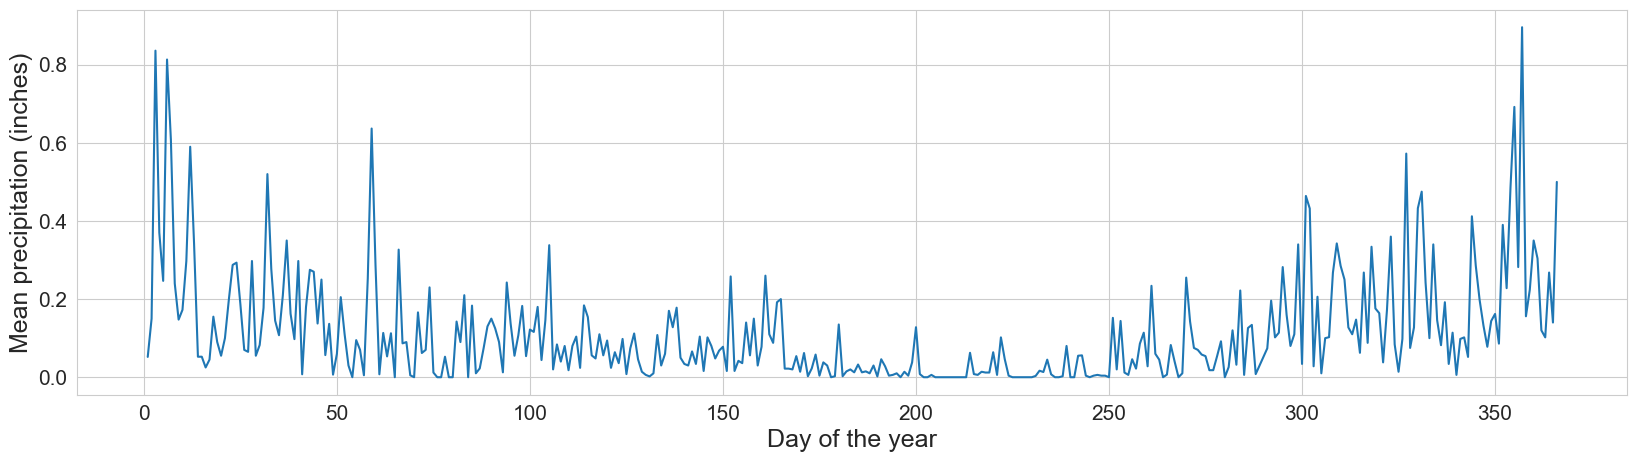

In [31]:
plt.figure(figsize=(20,5))

sns.lineplot(data=mean_day_precipitation, x='day_of_year', y='precipitation')

plt.xlabel('Day of the year', fontsize=18)
plt.ylabel('Mean precipitation (inches)', fontsize=18)

plt.tick_params(labelsize=15)

plt.show()

In [32]:
indices = np.where(df['precipitation'].isna() == True)[0]

In [33]:
for index in indices:
    df.loc[index,'precipitation'] = mean_day_precipitation.loc[df.loc[index, 'day_of_year']].values[0]

In [34]:
df.to_csv('/Users/michael/Documents/SeattleU/5100/Weather/data/clean_seattle_PHL_weather.csv', encoding='utf-8-sig', index=False)

# Analysis

*add note here about why it's not in a seperate notebook

In [38]:
# import CSV to dataframe
df = pd.read_csv("/Users/michael/Documents/SeattleU/5100/Weather/data/clean_seattle_PHL_weather.csv")

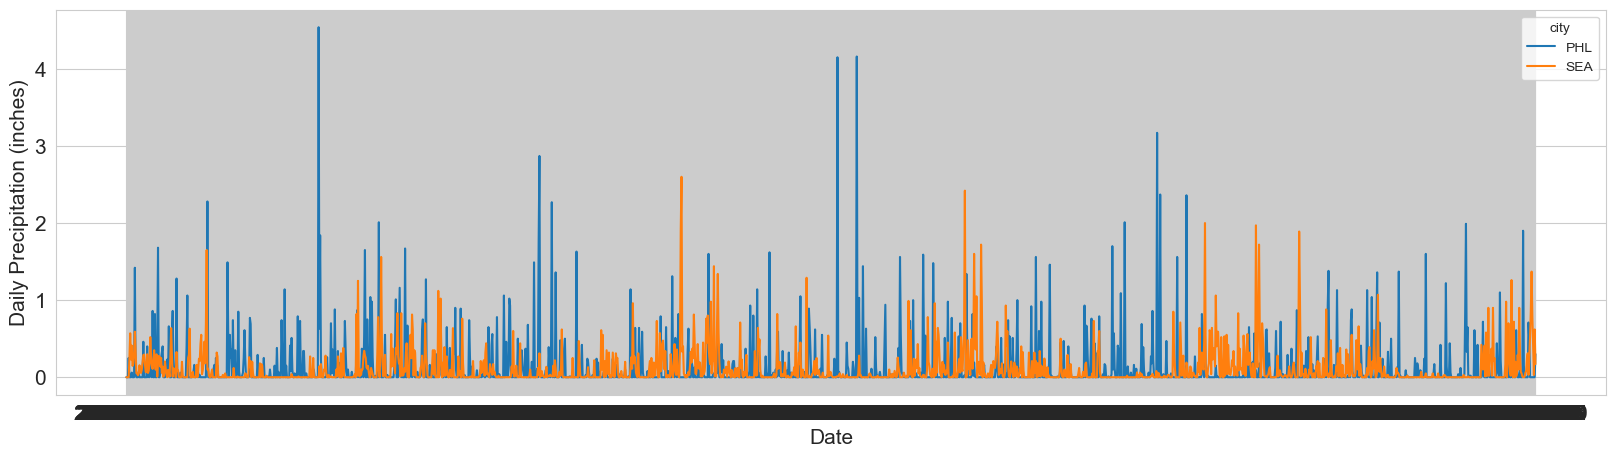

In [39]:
#create a plot to explore data for initial patterns
plt.figure(figsize=(20,5))

sns.lineplot(data=df, x='date', y='precipitation', hue='city')

plt.xlabel('Date', fontsize=15)
plt.ylabel('Daily Precipitation (inches)', fontsize=15)

plt.tick_params(labelsize=15)

plt.show()

In [40]:
#group the data by city and rainfall
df[['city','precipitation']].groupby('city').describe()

precipitation                                                
             count      mean       std  min  25%   50%   75%   max
city                                                              
PHL         1826.0  0.134189  0.362082  0.0  0.0  0.00  0.07  4.54
SEA         1826.0  0.113270  0.240516  0.0  0.0  0.01  0.12  2.60

In [41]:
#compare the daily average rainfall to view differences
df[['city','precipitation']].groupby('city').mean()

,precipitation
city,
PHL,0.134189
SEA,0.113270


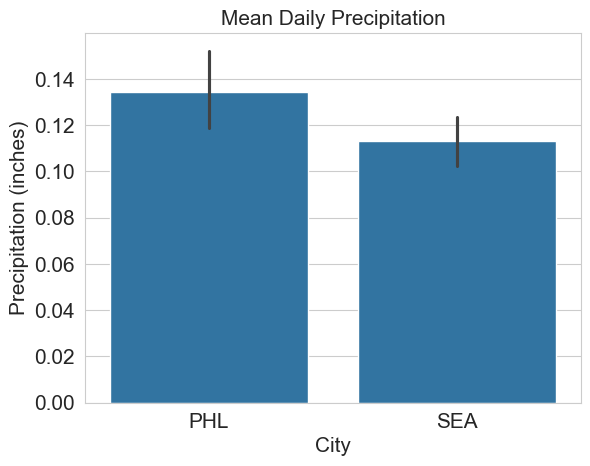

In [42]:
#create a barplot to compare mean rainfall
sns.barplot(data=df, x='city', y='precipitation')

plt.ylabel('Precipitation (inches)', fontsize=15)
plt.xlabel('City', fontsize=15)
plt.title('Mean Daily Precipitation', fontsize=15)

plt.tick_params(labelsize=15)

plt.show()

In [43]:
#create a new column called month and add a numerical value to represent the month, this make the data easier to visualize
df['month'] = pd.DatetimeIndex(df['date']).month

In [44]:
df.head()

,date,city,precipitation,day_of_year,month
0,2018-01-01,PHL,0.00,1,1
1,2018-01-02,PHL,0.00,2,1
2,2018-01-03,PHL,0.00,3,1
3,2018-01-04,PHL,0.25,4,1
4,2018-01-05,PHL,0.00,5,1


In [45]:
#Return all unique month value to ensure that there are individual months in the data
df['month'].unique()

array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12], dtype=int32)

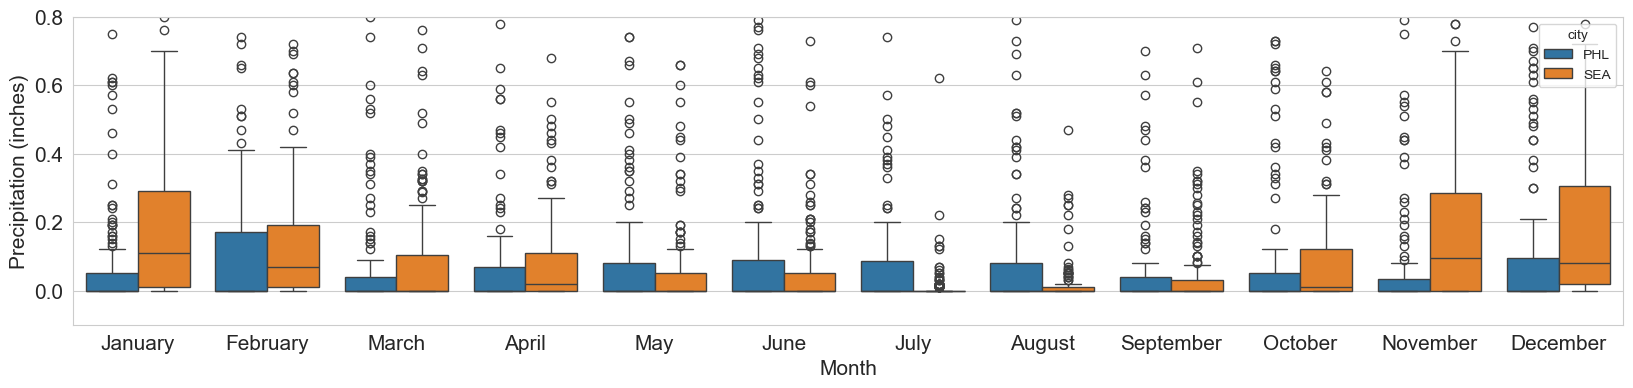

In [46]:
#Create a box plot to compare rainfall in different months
plt.figure(figsize=(20,4))

sns.boxplot(data=df, x='month', y='precipitation', hue='city')

plt.xlabel('Month', fontsize=15)
plt.ylabel('Precipitation (inches)', fontsize =15)
plt.ylim(-0.1, 0.8)

plt.tick_params(labelsize=15)

#Get month names and set x-axis tick labels
import calendar
month_names = list(calendar.month_name[1:])
plt.xticks(ticks=range(12), labels=month_names)

plt.show()

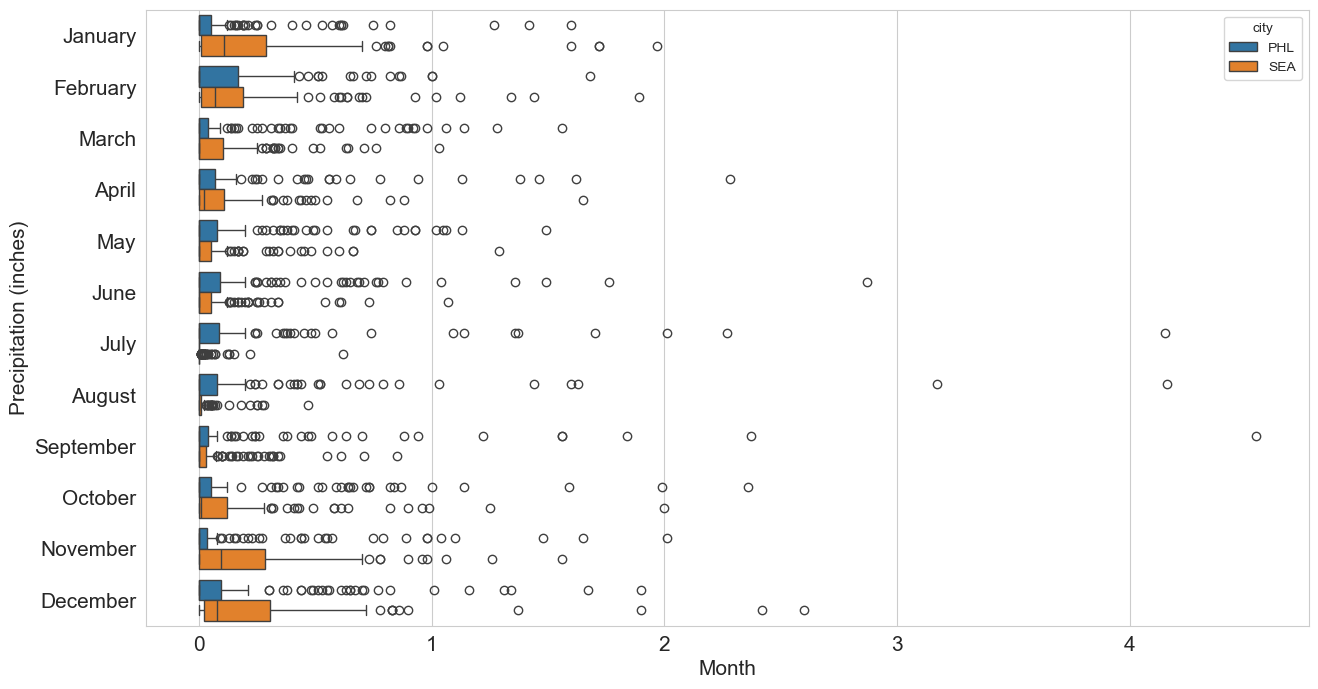

In [47]:
#Create a horizontal boxplot to better view data trends

plt.figure(figsize=(15,8))

sns.boxplot(data=df, x='precipitation', y='month', hue='city', orient='h')

plt.xlabel('Month', fontsize=15)
plt.ylabel('Precipitation (inches)', fontsize =15)

plt.tick_params(labelsize=15)
plt.yticks(ticks=range(12), labels=month_names)


plt.show()

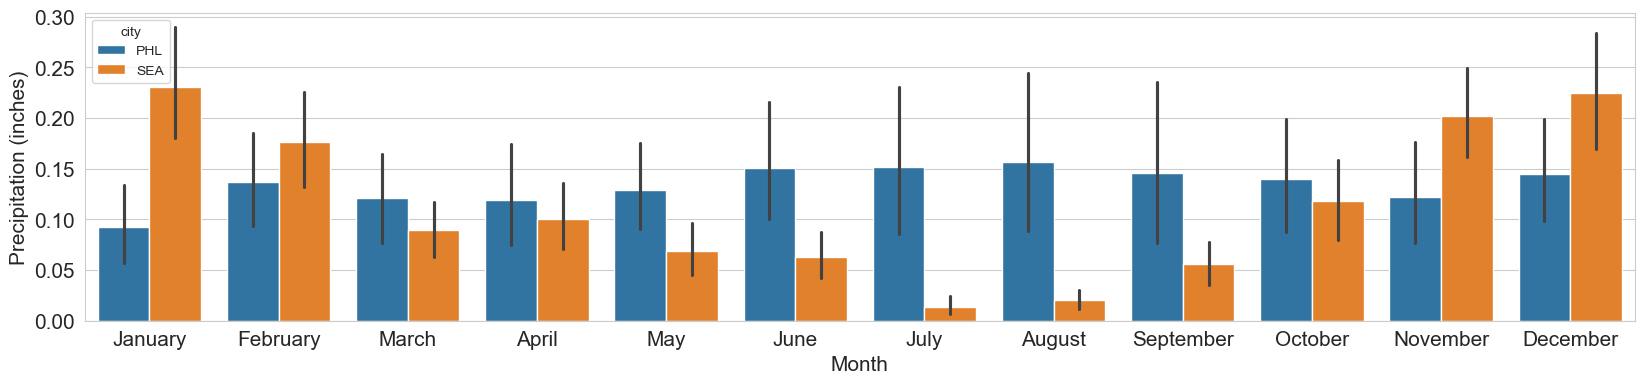

In [48]:
#This plots the mean precipitation each month

plt.figure(figsize=(20,4))

sns.barplot(data=df, x='month', y='precipitation', hue='city')

plt.xlabel('Month', fontsize=15)
plt.ylabel('Precipitation (inches)', fontsize=15)

plt.tick_params(labelsize=15)

plt.xticks(ticks=range(12), labels=month_names)

plt.show()

In [50]:
#Compute the mean precipitation each month

df[['month', 'precipitation', 'city']].groupby(['month','city']).mean()

precipitation
month city               
1     PHL        0.092323
      SEA        0.230742
2     PHL        0.136596
      SEA        0.176472
3     PHL        0.121484
      SEA        0.089075
4     PHL        0.119400
      SEA        0.100483
5     PHL        0.129226
      SEA        0.069161
6     PHL        0.150533
      SEA        0.063167
7     PHL        0.151935
      SEA        0.013984
8     PHL        0.156774
      SEA        0.019995
9     PHL        0.145467
      SEA        0.055622
10    PHL        0.139677
      SEA        0.118452
11    PHL        0.122200
      SEA        0.201867
12    PHL        0.144903
      SEA        0.224903

In [51]:
#Adds a variable to indicate whether there was any precipitation
df['any_precipitation'] = df['precipitation'] > 0

In [52]:
df.head()

,date,city,precipitation,day_of_year,month,any_precipitation
0,2018-01-01,PHL,0.00,1,1,False
1,2018-01-02,PHL,0.00,2,1,False
2,2018-01-03,PHL,0.00,3,1,False
3,2018-01-04,PHL,0.25,4,1,True
4,2018-01-05,PHL,0.00,5,1,False


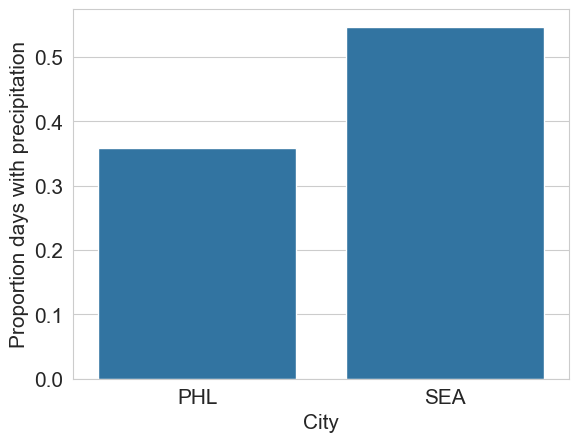

In [53]:
#Plot the proportion of days with any precipitation over the 5 years

sns.barplot(data=df, x='city', y='any_precipitation', errorbar=None)

plt.xlabel('City', fontsize=15)
plt.ylabel('Proportion days with precipitation', fontsize=15)

plt.tick_params(labelsize=15)

plt.show()

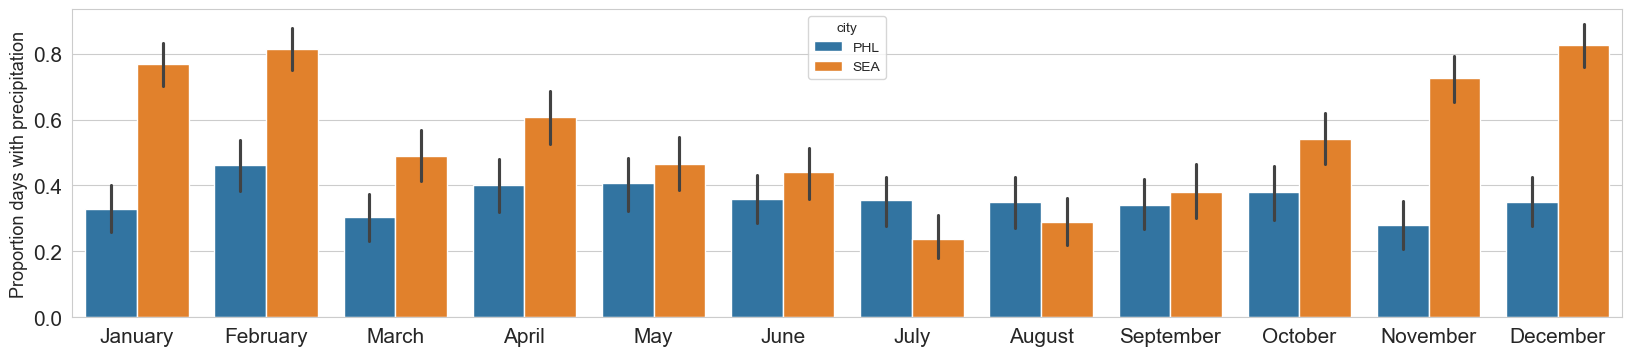

In [54]:
#Plot the proportion of days with precipitation each month

plt.figure(figsize=(20,4))

sns.barplot(data=df, x='month', y='any_precipitation', hue='city')

plt.xlabel(None)
plt.ylabel('Proportion days with precipitation', fontsize=13)
plt.xticks(ticks=range(12), labels=month_names)
plt.tick_params(labelsize=15)

plt.show()

In [ ]:
# Analysis P. 2

In [55]:
#Determine if findings are statistically significant 
from scipy import stats

significance_level = 0.05
significantly_different = np.zeros(12)

#Perform t-test for each month
for month in range(1,13):
    sea_data = df.loc[(df['city'] == 'SEA') & (df['month'] == month), 'precipitation']
    phl_data = df.loc[(df['city'] == 'PHL') & (df['month'] == month), 'precipitation']

    t_statistic, p_value = stats.ttest_ind(sea_data, phl_data, equal_var=False)

    if p_value < significance_level:
        significantly_different[month-1] = 1

    print(f"Month {month}:")
    print(f"  t statistic = {t_statistic:.2f}")
    print(f"  p-value t test = {t_statistic:.3f}")
    print("-" * 20)

Month 1:
  t statistic = 4.10
  p-value t test = 4.097
--------------------
Month 2:
  t statistic = 1.20
  p-value t test = 1.200
--------------------
Month 3:
  t statistic = -1.21
  p-value t test = -1.211
--------------------
Month 4:
  t statistic = -0.61
  p-value t test = -0.612
--------------------
Month 5:
  t statistic = -2.32
  p-value t test = -2.322
--------------------
Month 6:
  t statistic = -2.68
  p-value t test = -2.681
--------------------
Month 7:
  t statistic = -3.58
  p-value t test = -3.585
--------------------
Month 8:
  t statistic = -3.44
  p-value t test = -3.444
--------------------
Month 9:
  t statistic = -2.13
  p-value t test = -2.133
--------------------
Month 10:
  t statistic = -0.60
  p-value t test = -0.605
--------------------
Month 11:
  t statistic = 2.30
  p-value t test = 2.302
--------------------
Month 12:
  t statistic = 2.00
  p-value t test = 1.999
--------------------


In [56]:
#Perform a statistical test for the differences in the proportion of days with any precipitation each month between cities

from statsmodels.stats.proportion import proportions_ztest

significance_level = 0.05
significantly_different_proportion = np.zeros(12)

#perform t-test for each month
for month in range(1,13):

    #create a contingency tables for Seattle and Philadelphia for the current month
    contingency_table = pd.crosstab(
        df.loc[df['month']== month, 'city'], df.loc[df['month'] == month, 'any_precipitation']
    )

    #calculate the number of True values (days with precipitation) for each city
    days_with_precipitation = contingency_table[True]

    #calculate the total number of days for each city
    total_counts = contingency_table.sum(axis=1)

    #hypothesis test
    zstat, p_value = proportions_ztest(
        count=days_with_precipitation, nobs=total_counts, alternative='two-sided'
    )

    if p_value < significance_level:
        significantly_different_proportion[month-1]=1

    print(f"Month {month}:")
    print(f"  z-statistic = {zstat:.2f}")
    print(f"  p-value = {p_value:.3f}")
    print("-" * 20)
    




    


Month 1:
  z-statistic = -7.76
  p-value = 0.000
--------------------
Month 2:
  z-statistic = -6.20
  p-value = 0.000
--------------------
Month 3:
  z-statistic = -3.37
  p-value = 0.001
--------------------
Month 4:
  z-statistic = -3.58
  p-value = 0.000
--------------------
Month 5:
  z-statistic = -1.03
  p-value = 0.303
--------------------
Month 6:
  z-statistic = -1.41
  p-value = 0.157
--------------------
Month 7:
  z-statistic = 2.24
  p-value = 0.025
--------------------
Month 8:
  z-statistic = 1.10
  p-value = 0.273
--------------------
Month 9:
  z-statistic = -0.72
  p-value = 0.470
--------------------
Month 10:
  z-statistic = -2.85
  p-value = 0.004
--------------------
Month 11:
  z-statistic = -7.74
  p-value = 0.000
--------------------
Month 12:
  z-statistic = -8.54
  p-value = 0.000
--------------------


In [57]:
#output a contingency table
contingency_table = pd.crosstab(
    df.loc[df['month'] == 1, 'city'], df.loc[df['month'] == 1, 'any_precipitation']
)

contingency_table

any_precipitation,False,True
city,,
PHL,104,51
SEA,36,119


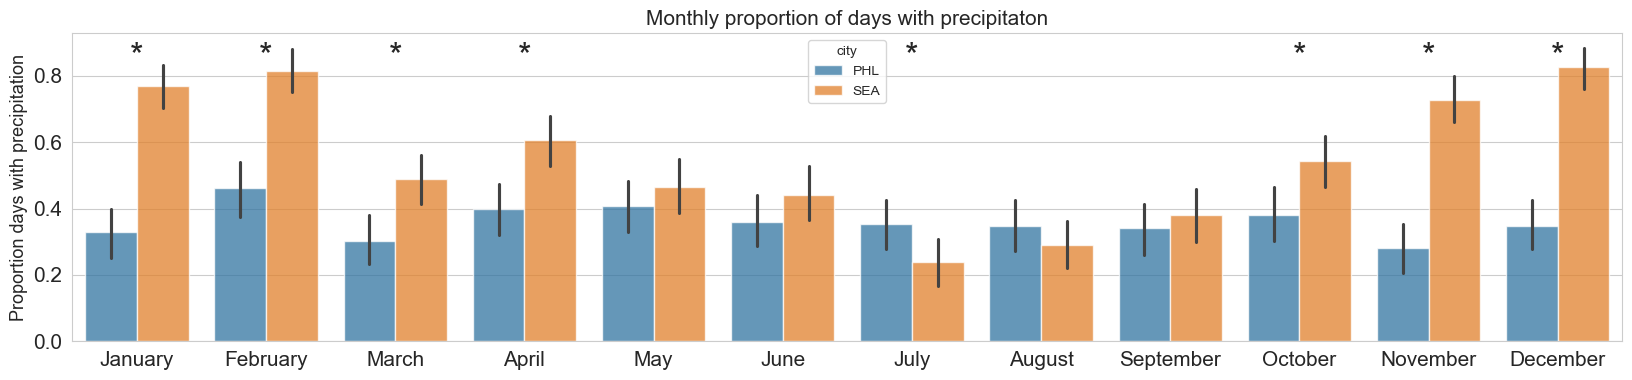

In [58]:
#Plot the proportion of days with any precipitation each month with a stat for significant differences

plt.figure(figsize=(20,4))

sns.barplot(data=df, x='month', y='any_precipitation', hue='city', alpha=0.75)

plt.xlabel(None)
plt.ylabel('Proportion days with precipitation', fontsize=13)
plt.title('Monthly proportion of days with precipitaton', fontsize=15)

plt.xticks(ticks=range(12), labels = month_names)
plt.tick_params(labelsize=15)

#add stars for significantly different months
for month in range(12):
    if significantly_different_proportion[month]==1:

        #add a star
        plt.text(month, 0.825, '*', ha='center', fontsize=25)


plt.show()